# Quick EDA on cleaned Telco data

This notebook loads the cleaned customer churn dataset and gives a compact snapshot of the schema, missing values, churn balance, and a couple of quick plots.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

csv_path = Path("..") / "data" / "processed" / "cleaned_telco.csv"
df = pd.read_csv(csv_path)

print(f"Shape: {df.shape}")
display(df.head())

display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}).sort_values(["missing", "dtype"], ascending=[False, True]))

print("\nChurn balance:")
display((df["Churn"].value_counts(dropna=False).rename_axis("Churn").to_frame("count").assign(pct=lambda x: (x["count"] / len(df) * 100).round(2))))

num_cols = df.select_dtypes(include="number").columns.tolist()
if num_cols:
    display(df[num_cols].describe().T)

cat_cols = df.select_dtypes(exclude="number").columns.tolist()
cat_cols = [col for col in cat_cols if col != "Churn"]
summary_rows = []
for col in cat_cols[:5]:
    top = df[col].value_counts(dropna=False).head(3)
    summary_rows.append({
        "column": col,
        "top_values": "; ".join(f"{idx}: {val}" for idx, val in top.items()),
    })

if summary_rows:
    display(pd.DataFrame(summary_rows))

Matplotlib is building the font cache; this may take a moment.


Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,dtype,missing,missing_pct
MonthlyCharges,float64,0,0.0
TotalCharges,float64,0,0.0
SeniorCitizen,int64,0,0.0
tenure,int64,0,0.0
gender,object,0,0.0
Partner,object,0,0.0
Dependents,object,0,0.0
PhoneService,object,0,0.0
MultipleLines,object,0,0.0
InternetService,object,0,0.0



Churn balance:


,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.000,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80


,column,top_values
0,gender,Male: 3555; Female: 3488
1,Partner,No: 3641; Yes: 3402
2,Dependents,No: 4933; Yes: 2110
3,PhoneService,Yes: 6361; No: 682
4,MultipleLines,No: 3390; Yes: 2971; No phone service: 682


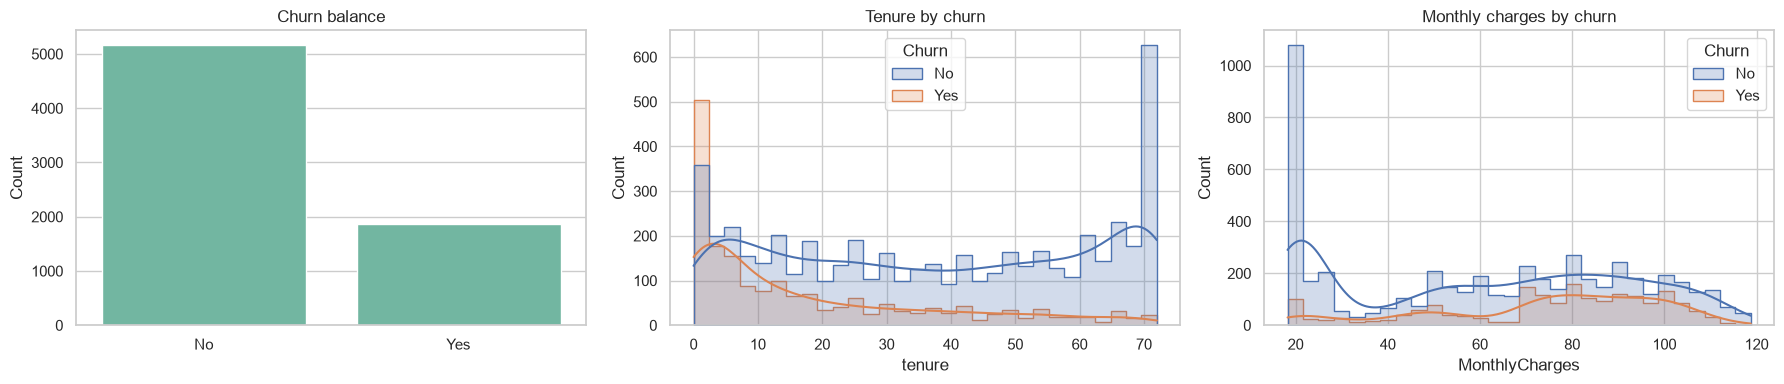

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="Churn", ax=axes[0], color=sns.color_palette("Set2")[0])
axes[0].set_title("Churn balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, element="step", ax=axes[1])
axes[1].set_title("Tenure by churn")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True, element="step", ax=axes[2])
axes[2].set_title("Monthly charges by churn")

plt.tight_layout()
plt.show()